In [1]:
import torch
import numpy as np
from PIL import Image
import requests

In [2]:
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

运行下方程序即可输出在图像上标记出类别和坐标信息

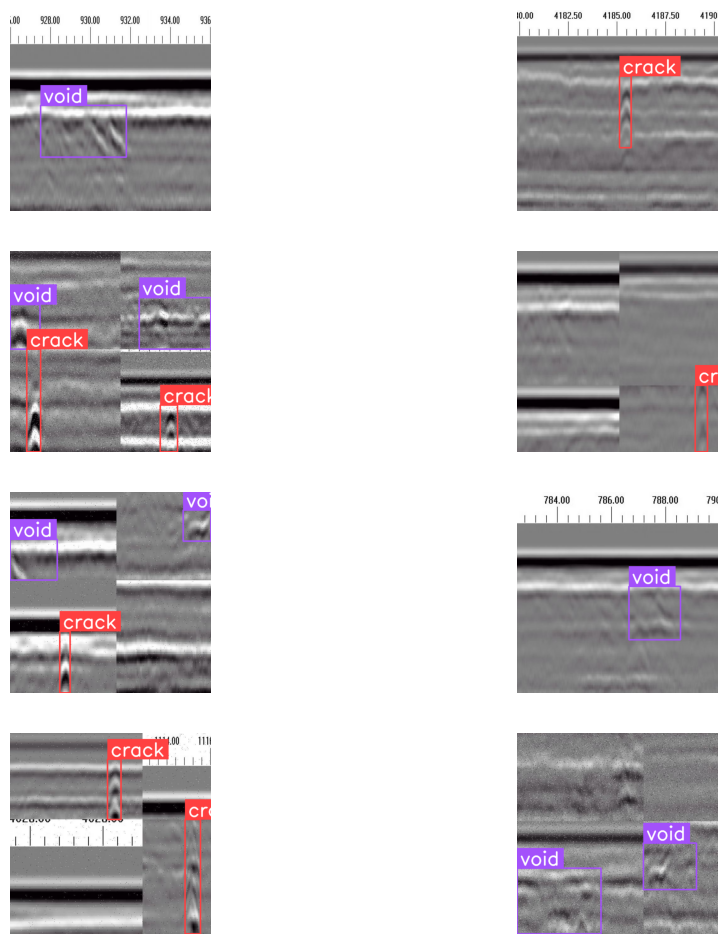

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'area', 'box_area', 'class_id', 'confidence', 'data', 'empty', 'from_azure_analyze_image', 'from_deepsparse', 'from_detectron2', 'from_inference', 'from_lmm', 'from_mmdetection', 'from_paddledet', 'from_roboflow', 'from_sam', 'from_tensorflow', 'from_transformers', 'from_ultralytics', 'from_yolo_nas', 'from_yolov5', 'get_anchors_coordinates', 'is_empty', 'mask', 'merge', 'tracker_id', 'with_nmm', 'with_nms', 'xyxy']


In [15]:
####运行程序即可输出图像和目标检测标签#######

import cv2
import json
import supervision as sv
from typing import List

def read_n_lines(file_path: str, n: int) -> List[str]:
    with open(file_path, 'r') as file:
        lines = [next(file).strip() for _ in range(n)]
    return lines

images = []
lines = read_n_lines(f"/root/model/p-1.v1i.paligemma/dataset/_annotations.train1.jsonl", 8)
first = json.loads(lines[0])

CLASSES = first.get('prefix').replace("detect ", "").split(" ; ")

for line in lines:
    data = json.loads(line)
    image = cv2.imread(f"/root/model/p-1.v1i.paligemma/dataset/{data.get('image')}")
    (h, w, _) = image.shape
    detections = sv.Detections.from_lmm(
        lmm='paligemma',
        result=data.get('suffix'),
        resolution_wh=(w, h),
        classes=CLASSES)######在这个sv.Dtections.from_lmm中定义了如何将paligemma的格式坐标转移为图像上的坐标。
    
    image = sv.BoundingBoxAnnotator(thickness=4).annotate(image, detections)
    image = sv.LabelAnnotator(text_scale=2, text_thickness=4).annotate(image, detections)
    images.append(image)

sv.plot_images_grid(images, (4, 2))
print(dir(detections))

In [4]:
############检查环境路径

import os
import sys

# 获取当前工作目录
current_dir = os.getcwd()

# 构建 big_vision_repo 的路径
big_vision_path = os.path.join(current_dir, "big_vision_repo")

# 添加 big_vision_repo 到 PYTHONPATH
os.environ["PYTHONPATH"] = os.environ.get("PYTHONPATH", "") + os.pathsep + big_vision_path

# 确保 Python 知道 big_vision_repo 的位置
sys.path.append(big_vision_path)

# 验证 PYTHONPATH 是否设置成功
print(f"PYTHONPATH is set to: {os.environ['PYTHONPATH']}")

PYTHONPATH is set to: :/root/big_vision_repo


In [5]:
import os

# Step 1: Clone the big_vision repository
if not os.path.exists("big_vision_repo"):
    !git clone --quiet --branch=main --depth=1 https://github.com/google-research/big_vision big_vision_repo

# Step 2: Set the PYTHONPATH environment variable
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':' + os.path.abspath("big_vision_repo")

# Verify the PYTHONPATH
print("PYTHONPATH is set to:", os.environ['PYTHONPATH'])#####配置环境路径

PYTHONPATH is set to: :/root/big_vision_repo:/root/big_vision_repo


In [6]:
import os

# Step 1: Clone the big_vision repository
if not os.path.exists("big_vision_repo"):
    !git clone --quiet --branch=main --depth=1 https://github.com/google-research/big_vision big_vision_repo

# Step 2: Set the PYTHONPATH environment variable
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':' + os.path.abspath("big_vision_repo")

# Verify the PYTHONPATH
print("PYTHONPATH is set to:", os.environ['PYTHONPATH'])#####配置环境路径

PYTHONPATH is set to: :/root/big_vision_repo:/root/big_vision_repo:/root/big_vision_repo


In [7]:
######检查环境是否配置成功

try:
    import big_vision
    print("big_vision module imported successfully")
except ImportError as e:
    print(f"Error importing big_vision: {e}")

big_vision module imported successfully


In [8]:
####导入相关的数据包

import base64
import functools
import html
import io
import os
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import ml_collections

import tensorflow as tf
import sentencepiece

from IPython.display import display, HTML

import torch  # 确保导入 torch
from PIL import Image

# Import model definition from big_vision
from big_vision.models.proj.paligemma import paligemma
from big_vision.trainers.proj.paligemma import predict_fns

# Import big vision utilities
import big_vision.datasets.jsonl
import big_vision.utils
import big_vision.sharding

2024-09-18 09:59:19.589830: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [9]:
# 设置本地文件路径
MODEL_PATH = "/root/model/paligemma-3b-pt-224.f16.npz"######官网模型
#MODEL_PATH = "/root/autodl-tmp/model-out-7/latest_model_weights.npz"
TOKENIZER_PATH = "/root/model/paligemma_tokenizer.model"
dataset_location = "/root/model/p-1.v1i.paligemma"
#dataset_location = "E://ybx_GPR_test_paligemma//GPR.v3-b-scans-without-noise.paligemma"
# 加载模型示例######定义一个函数用来加载模型，这个模型的路径是在D盘中的可以后续更改，使用NUmP加载模型
def load_model(model_path):
    print(f"Loading model from {model_path}...")
    model = np.load(model_path)  # 使用 NumPy 加载模型
    return model

# 加载标记器示例######加载模型的标记器这个标记器就是用来处理paligemma的文本数据，将这个文本转换为模型可以理解的数字来表示让模型能够读取文字。
def load_tokenizer(tokenizer_path):######################在加载模型的时候一定要注意模型可以直接加载但是对于tokenizer需要转置为二进制再去读取模型的参数，
    print(f"Loading tokenizer from {tokenizer_path}...")#######这是英文tokenizer中包含着处理文本和映射的规则这些数据通常需要存储为序列化对象，这些序列格式需要被反序列化才能python使用
    with open(tokenizer_path, 'rb') as f:####以二进制的形式打开文件
        tokenizer = f.read()  # 根据标记器的实际格式调整
    return tokenizer

# 加载模型和标记器
model = load_model(MODEL_PATH)######加载模型，调用刚才的模型加载函数
tokenizer = load_tokenizer(TOKENIZER_PATH)#####加载标记器，调用刚才定义的tokenizer加载函数
print("Model and tokenizer loaded successfully.")#输出模型和标记器加载成功

# 不要限制TF使用GPU或TPU
# tf.config.set_visible_devices([], "GPU")
# tf.config.set_visible_devices([], "TPU")

# 检查是否有GPU可用
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # 设置GPU使用限制为按需增长，而不是预先分配所有的显存
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

backend = jax.lib.xla_bridge.get_backend()
print(f"JAX version:  {jax.__version__}")
print(f"JAX platform: {backend.platform}")
print(f"JAX devices:  {jax.device_count()}")#####输出当前JAX的版本。

# 如果你希望JAX使用GPU，确保CUDA和cuDNN已正确安装并配置
if backend.platform == 'gpu':
    print("JAX is using GPU")
else:
    print("JAX is not using GPU, check your CUDA/cuDNN installation.")#####验证JAX是否可以正确调用GPU如果不能使用GPU 的话就直接使用CPU.

Loading model from /root/model/paligemma-3b-pt-224.f16.npz...
Loading tokenizer from /root/model/paligemma_tokenizer.model...
Model and tokenizer loaded successfully.
JAX version:  0.4.29
JAX platform: gpu
JAX devices:  1
JAX is using GPU


In [10]:
# Define model###设置一个不可改变的字典变量,,,,llm表是paligemma中的文本模型是lam
model_config = ml_collections.FrozenConfigDict({
    "llm": {"vocab_size": 257_152},########llm表示的是large language model ,257_152是表示paligemma可以处理的文字表示模型的词汇量为257,152。这意味着模型可以识别和处理257,152个不同的单词或字符。
    "img": {"variant": "So400m/14", "pool_type": "none", "scan": True, "dtype_mm": "float16"}
})##################################################variant: 指定视觉模型的变体，这里是"So400m/14"。这表示模型基于So400m模型架构，并使用14个层。pool_type: 指定池化层的类型，这里是"none"。这表示不使用池化层。
############scan: 指定是否扫描图像，这里是True。这表示模型会扫描图像以提取特征。
#################dtype_mm: 指定模型内部计算的数据类型，这里是"float16"。这表示使用半精度浮点数，可以提高模型的计算效率。
model = paligemma.Model(**model_config)####python语句塘，就是将字典里面的对应的key 和value 分别传入到模型中。
tokenizer = sentencepiece.SentencePieceProcessor(TOKENIZER_PATH)
####SentencePiece是Google开发的一种文本处理工具，用于将文本分割为单词或字符等更小的单位，
#####并将其转换为模型可以理解的数字表示。PaliGemma模型使用SentencePiece进行文本处理，因此需要加载SentencePiece的标记器。sentencepiece.SentencePieceProcessor
####是SentencePiece库中的一个类，用于加载和使用标记器。它提供了各种方法来处理文本，例如：将文本转换为数字表示；将数字表示转换为文本；获取词表大小；获取词汇列表

#######加载参数
params = paligemma.load(None, MODEL_PATH, model_config)

# 定义 `decode` 函数以从模型中采样输出。这段代码定义了 decode 函数，用于从 PaliGemma 模型中采样文本输出。
decode_fn = predict_fns.get_all(model)['decode']
decode = functools.partial(decode_fn, devices=jax.devices(), eos_token=tokenizer.eos_id())#####指定解码函数使用的终止标记，这里是标记器中表示结束的标记的ID。

# 将参数移至 GPU 内存
def is_trainable_param(name, param):
    if name.startswith("llm/layers/attn/"):  return True
    if name.startswith("llm/"):              return False
    if name.startswith("img/"):              return False
    raise ValueError(f"Unexpected param name {name}")
##############按照数据维度分片微调模型参数只调整部分参数，大部分参数是冻结的########################
trainable_mask = big_vision.utils.tree_map_with_names(is_trainable_param, params)###这行代码遍历模型参数，并根据 is_trainable_param 函数的结果，创建一个 trainable_mask 标识符。该标识符用来标记哪些参数是可训练的。

mesh = jax.sharding.Mesh(jax.devices(), ("data"))###jax.sharding.Mesh 用于创建分片方案（sharding scheme），jax.devices() 获取可用的 JAX 设备列表。("data") 指定数据分片维度。这表示数据将沿着 "data" 维度进行分片。

data_sharding = jax.sharding.NamedSharding(mesh, jax.sharding.PartitionSpec("data"))#####jax.sharding.NamedSharding是基于mesh分片方案创建命名分片，然后按照data的维度进行划分。

params_sharding = big_vision.sharding.infer_sharding(params, strategy=[('.*', 'fsdp(axis="data")')], mesh=mesh)####按照完全分片的方式进行分片，并且沿着data维度进行划分。

warnings.filterwarnings("ignore", message="Some donated buffers were not usable")######忽略部分缓冲数据区不能使用的警告

@functools.partial(jax.jit, donate_argnums=(0,), static_argnums=(1,))######就是通过修复原始函数创建新的函数，捐赠的函数参数是由dnoate=0，表示第一个参数不变，不需要微调，，static=1第二个参数需要微调
def maybe_cast_to_f32(params, trainable):######导入参数和可训练的参数
    return jax.tree.map(lambda p, m: p.astype(jnp.float32) if m else p, params, trainable)####tree.map是用来遍历参数的P表示单个参数，m表示需要训练的单个元素。如果是m需要训练的话，参数p就是被强制转化成32为的数据。

params, treedef = jax.tree.flatten(params)
sharding_leaves = jax.tree.leaves(params_sharding)
trainable_leaves = jax.tree.leaves(trainable_mask)#######将params,params_sharding,trainable_mask定义和的参数传入函数。
######就是判断参数是否需要训练,如果需要训练的话就把转为需要训练的float32字符类型,然后再把训练完的参数转为模型最初的形式。
for idx, (sharding, trainable) in enumerate(zip(sharding_leaves, trainable_leaves)):
    params[idx] = big_vision.utils.reshard(params[idx], sharding)
    params[idx] = maybe_cast_to_f32(params[idx], trainable)
    params[idx].block_until_ready()
params = jax.tree.unflatten(treedef, params)#######将训练后的参数还原到模型参数中保持与原来模型参数一致。

def parameter_overview(params):
    for path, arr in big_vision.utils.tree_flatten_with_names(params)[0]:
        print(f"{path:80s} {str(arr.shape):22s} {arr.dtype}")###一个是80个字符，一个是22个字符

print(" == Model params == ")
parameter_overview(params)######遍历打印参数信息。

2024-09-18 09:59:32.746302: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.5.40). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


 == Model params == 
img/Transformer/encoder_norm/bias                                                (1152,)                float16
img/Transformer/encoder_norm/scale                                               (1152,)                float16
img/Transformer/encoderblock/LayerNorm_0/bias                                    (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_0/scale                                   (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_1/bias                                    (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_1/scale                                   (27, 1152)             float16
img/Transformer/encoderblock/MlpBlock_0/Dense_0/bias                             (27, 4304)             float16
img/Transformer/encoderblock/MlpBlock_0/Dense_0/kernel                           (27, 1152, 4304)       float16
img/Transformer/encoderblock/MlpBlock_0/Dense_1/bias                             (2

In [11]:
def preprocess_image(image, size=224):
  # Model has been trained to handle images of different aspects ratios
  # resized to 224x224 in the range [-1, 1]. Bilinear and antialias resize
  # options are helpful to improve quality in some tasks.
  image = np.asarray(image)
  if image.ndim == 2:  # Convert image without last channel into greyscale.
    image = np.stack((image,)*3, axis=-1)
  image = image[..., :3]  # Remove alpha layer.
  assert image.shape[-1] == 3

  image = tf.constant(image)
  image = tf.image.resize(image, (size, size), method='bilinear', antialias=True)
  return image.numpy() / 127.5 - 1.0  # [0, 255]->[-1,1]

def preprocess_tokens(prefix, suffix=None, seqlen=None):
  # Model has been trained to handle tokenized text composed of a prefix with
  # full attention and a suffix with causal attention.
  separator = "\n"
  tokens = tokenizer.encode(prefix, add_bos=True) + tokenizer.encode(separator)
  mask_ar = [0] * len(tokens)    # 0 to use full attention for prefix.
  mask_loss = [0] * len(tokens)  # 0 to not use prefix tokens in the loss.

  if suffix:
    suffix = tokenizer.encode(suffix, add_eos=True)
    tokens += suffix
    mask_ar += [1] * len(suffix)    # 1 to use causal attention for suffix.
    mask_loss += [1] * len(suffix)  # 1 to use suffix tokens in the loss.

  mask_input = [1] * len(tokens)    # 1 if it's a token, 0 if padding.
  if seqlen:
    padding = [0] * max(0, seqlen - len(tokens))
    tokens = tokens[:seqlen] + padding
    mask_ar = mask_ar[:seqlen] + padding
    mask_loss = mask_loss[:seqlen] + padding
    mask_input = mask_input[:seqlen] + padding

  return jax.tree.map(np.array, (tokens, mask_ar, mask_loss, mask_input))

#####不加confidence
def postprocess_tokens(tokens):
  tokens = tokens.tolist()  # np.array to list[int]
  try:  # Remove tokens at and after EOS if any.
    eos_pos = tokens.index(tokenizer.eos_id())
    tokens = tokens[:eos_pos]
  except ValueError:
    pass
  return tokenizer.decode(tokens)






In [12]:
SEQLEN = 128
dataset_location = "/root/model/p-1.v1i.paligemma"
train_dataset = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location, "dataset/_annotations.train1.jsonl"),
    fopen_keys={"image": f"{dataset_location}/dataset"})
    #fopen_keys={"image": dataset_location })

val_dataset = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location, "dataset/_annotations.valid1.jsonl"),
    fopen_keys={"image": f"{dataset_location}/dataset"})


def train_data_iterator():
  """Never ending iterator over training examples."""
  # Shuffle examples and repeat so one can train for many epochs.
  dataset = train_dataset.get_tfdata().shuffle(1_000).repeat()
  for example in dataset.as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = example["prefix"].decode().lower()
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, mask_loss, _ = preprocess_tokens(prefix, suffix, SEQLEN)
    label, _, _, _ = preprocess_tokens(suffix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "label": np.asarray(label),
        "mask_ar": np.asarray(mask_ar),
        "mask_loss": np.asarray(mask_loss),
    }


def validation_data_iterator_valued():
  """Single iterator over validation examples."""
  for example in val_dataset.get_tfdata(ordered=True).as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = example["prefix"].decode().lower()
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)
    label, _, _, _ = preprocess_tokens(suffix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "label": np.asarray(label),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }

def validation_data_iterator_trained():
  """Single iterator over validation examples."""
  for example in train_dataset.get_tfdata(ordered=True).as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = example["prefix"].decode().lower()
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)
    label, _, _, _ = preprocess_tokens(suffix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "label": np.asarray(label),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }




Training examples



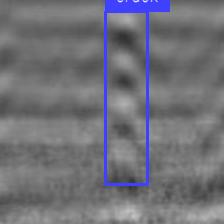
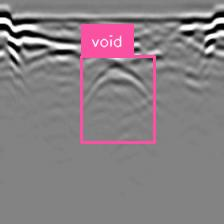
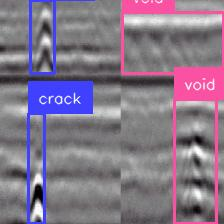
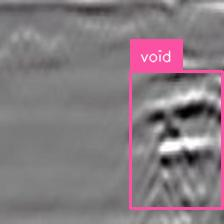
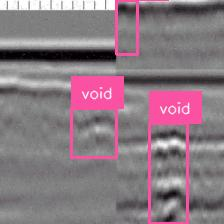
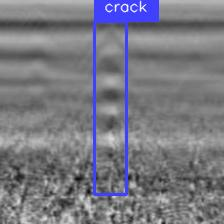
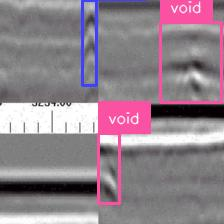
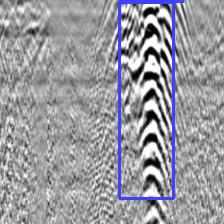
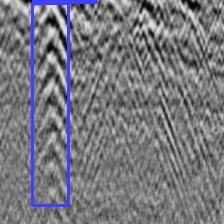
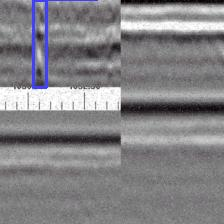
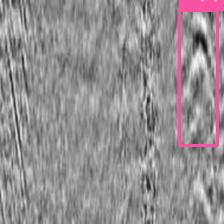
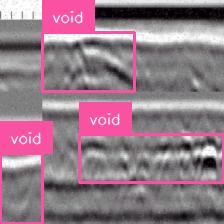
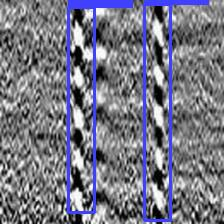
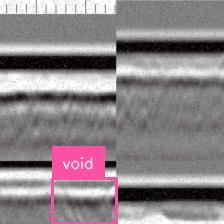
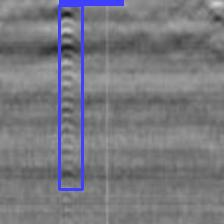
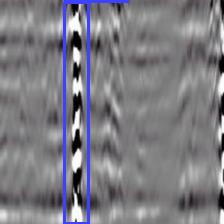
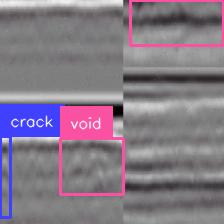
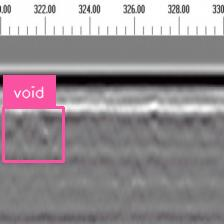
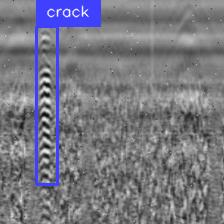
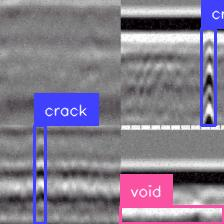

In [13]:
def read_n_lines(file_path: str, n: int) -> List[str]:#########for_object_detect
    lines = []
    with open(file_path, 'r') as file:
        for _ in range(n):
            line = file.readline()
            if not line:
                break
            lines.append(line.strip())
    return lines




def split_and_keep_second_part(s):##################for_object_detect
    parts = s.split('\n', 1)
    if len(parts) > 1:
        return parts[1]
    return s

def render_inline(image, resize=(128, 128)):#########for_object_detect and for_multi
    """Convert image into inline html."""
    image = Image.fromarray(image)
    image.resize(resize)
    with io.BytesIO() as buffer:
        image.save(buffer, format='jpeg')
        image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
        return f"data:image/jpeg;base64,{image_b64}"
######不加confidence####

def render_example(image, caption):
    image = ((image + 1)/2 * 255).astype(np.uint8)  # [-1,1] -> [0, 255]
    h, w, _ = image.shape
    try:
        detections = sv.Detections.from_lmm(
            lmm='paligemma',
            result=caption,
            resolution_wh=(w, h),
            classes=CLASSES)
        image = sv.BoundingBoxAnnotator().annotate(image, detections)
        image = sv.LabelAnnotator().annotate(image, detections)
    except:
        print(caption)
    return f"""
<div style="display: inline-flex; align-items: center; justify-content: center;">
    <img style="width:128px; height:128px;" src="{render_inline(image, resize=(64,64))}" />
    <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</p>
</div>
"""








html_out = ""
for idx, example in zip(range(20), train_data_iterator()):
    caption = postprocess_tokens(example["text"])  # detokenize model input.
    caption = split_and_keep_second_part(caption)
    
    html_out += render_example(example["image"], caption)

print("Training examples")
display(HTML(html_out))



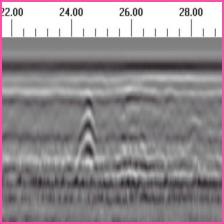
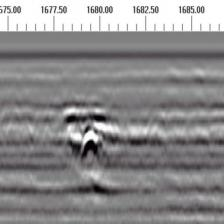
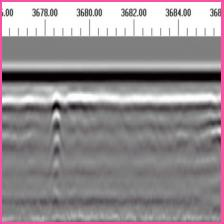
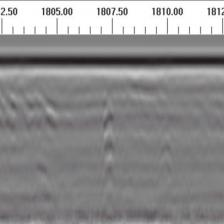
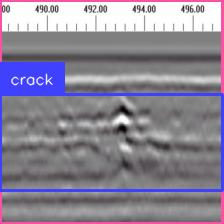
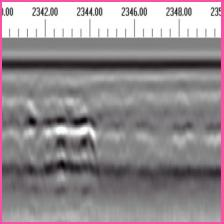
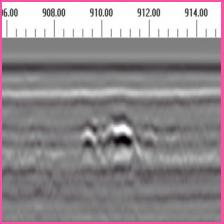
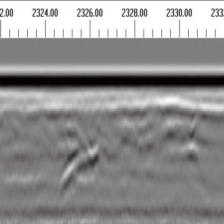
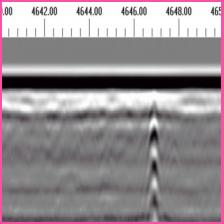
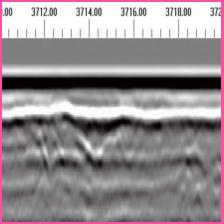
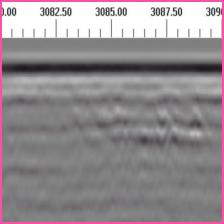
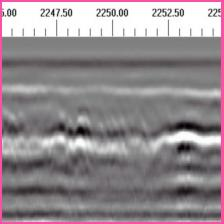
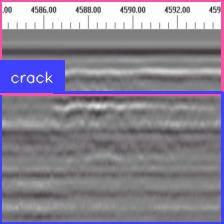
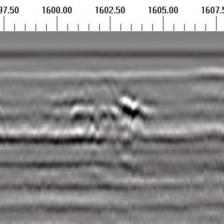
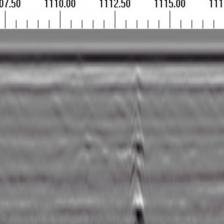
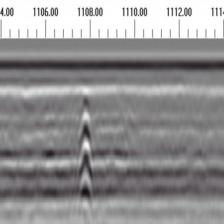
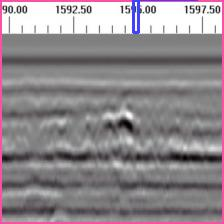
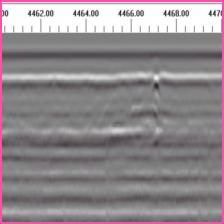
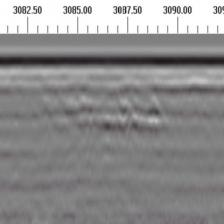
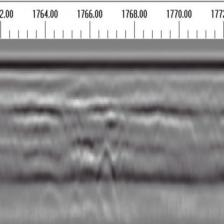

In [14]:
# The main update_fn using a simple stochastic gradient descent (SGD).
@functools.partial(jax.jit, donate_argnums=(0,))
def update_fn(params, batch, learning_rate):
  imgs, txts, mask_ar = batch["image"], batch["text"], batch["mask_ar"]

  def loss_fn(params):
    text_logits, _ = model.apply({"params": params}, imgs, txts[:, :-1], mask_ar[:, :-1], train=True)
    logp = jax.nn.log_softmax(text_logits, axis=-1)

    # The model takes as input txts[:, :-1] but the loss is defined as predicting
    # next tokens txts[:, 1:]. Additionally, mask_loss[:, 1:] indicates which tokens
    # are part of the loss (e.g. prefix and padded tokens are not included).
    mask_loss = batch["mask_loss"][:, 1:]
    targets = jax.nn.one_hot(txts[:, 1:], text_logits.shape[-1])

    # Compute the loss per example. i.e. the mean of per token pplx.
    # Since each example has a different number of tokens we normalize it.
    token_pplx = jnp.sum(logp * targets, axis=-1)  # sum across vocab_size.
    example_loss = -jnp.sum(token_pplx * mask_loss, axis=-1)  # sum across seq_len.
    example_loss /= jnp.clip(jnp.sum(mask_loss, -1), 1)  # weight by num of tokens.

    # batch_loss: mean of per example loss.
    return jnp.mean(example_loss)

  loss, grads = jax.value_and_grad(loss_fn)(params)

  # Apply gradients to trainable params using SGD.
  def apply_grad(param, gradient, trainable):
    if not trainable: return param
    return param - learning_rate * gradient

  params = jax.tree_util.tree_map(apply_grad, params, grads, trainable_mask)

  return params, loss

# Evaluation/inference loop.
def make_predictions(data_iterator, *, num_examples=None,
                     batch_size=4, seqlen=SEQLEN, sampler="greedy"):
  outputs = []
  while True:
    # Construct a list of examples in the batch.
    examples = []
    try:
      for _ in range(batch_size):
        examples.append(next(data_iterator))
        examples[-1]["_mask"] = np.array(True)  # Indicates true example.
    except StopIteration:
      if len(examples) == 0:
        return outputs

    # Not enough examples to complete a batch. Pad by repeating last example.
    while len(examples) % batch_size:
      examples.append(dict(examples[-1]))
      examples[-1]["_mask"] = np.array(False)  # Indicates padding example.

    # Convert list of examples into a dict of np.arrays and load onto devices.
    batch = jax.tree.map(lambda *x: np.stack(x), *examples)
    batch = big_vision.utils.reshard(batch, data_sharding)

    # Make model predictions
    tokens = decode({"params": params}, batch=batch,
                    max_decode_len=seqlen, sampler=sampler)

    # Fetch model predictions to device and detokenize.
    tokens, mask = jax.device_get((tokens, batch["_mask"]))
    tokens = tokens[mask]  # remove padding examples.
    labels = [postprocess_tokens(e["label"]) for e in examples]
    responses = [postprocess_tokens(t) for t in tokens]

    # Append to html output.
    for example, label, response in zip(examples, labels, responses):
      outputs.append((example["image"], label, response))
      if num_examples and len(outputs) >= num_examples:
        return outputs






###没有微调前的结果
html_out = ""
for image, _, caption in make_predictions(validation_data_iterator_valued(), num_examples=20, batch_size=4):
    html_out += render_example(image, caption)
display(HTML(html_out))




Epoch 1/100: 100%|██████████| 246/246 [03:40<00:00,  1.12it/s]


Epoch 1/100 - Loss: 3.6429, Time: 220.62 sec


Epoch 2/100: 100%|██████████| 246/246 [02:54<00:00,  1.41it/s]


Epoch 2/100 - Loss: 3.2921, Time: 174.13 sec


Epoch 3/100: 100%|██████████| 246/246 [02:54<00:00,  1.41it/s]


...

Epoch 99/100 - mAP@50_t: 0.99, mAP@75_t: 0.99, mAP@50-95_t: 0.99, mAP@50_v: 0.85, mAP@75_v: 0.41, mAP@50-95_v: 0.45


Epoch 100/100: 100%|██████████| 246/246 [02:52<00:00,  1.42it/s]


Epoch 100/100 - Loss: 0.0210, Time: 172.97 sec


2024-09-18 16:43:40.634737: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-09-18 16:44:04.109524: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 100/100 - mAP@50_t: 0.99, mAP@75_t: 0.99, mAP@50-95_t: 0.99, mAP@50_v: 0.84, mAP@75_v: 0.40, mAP@50-95_v: 0.44
程序运行时间: 24233.48 秒


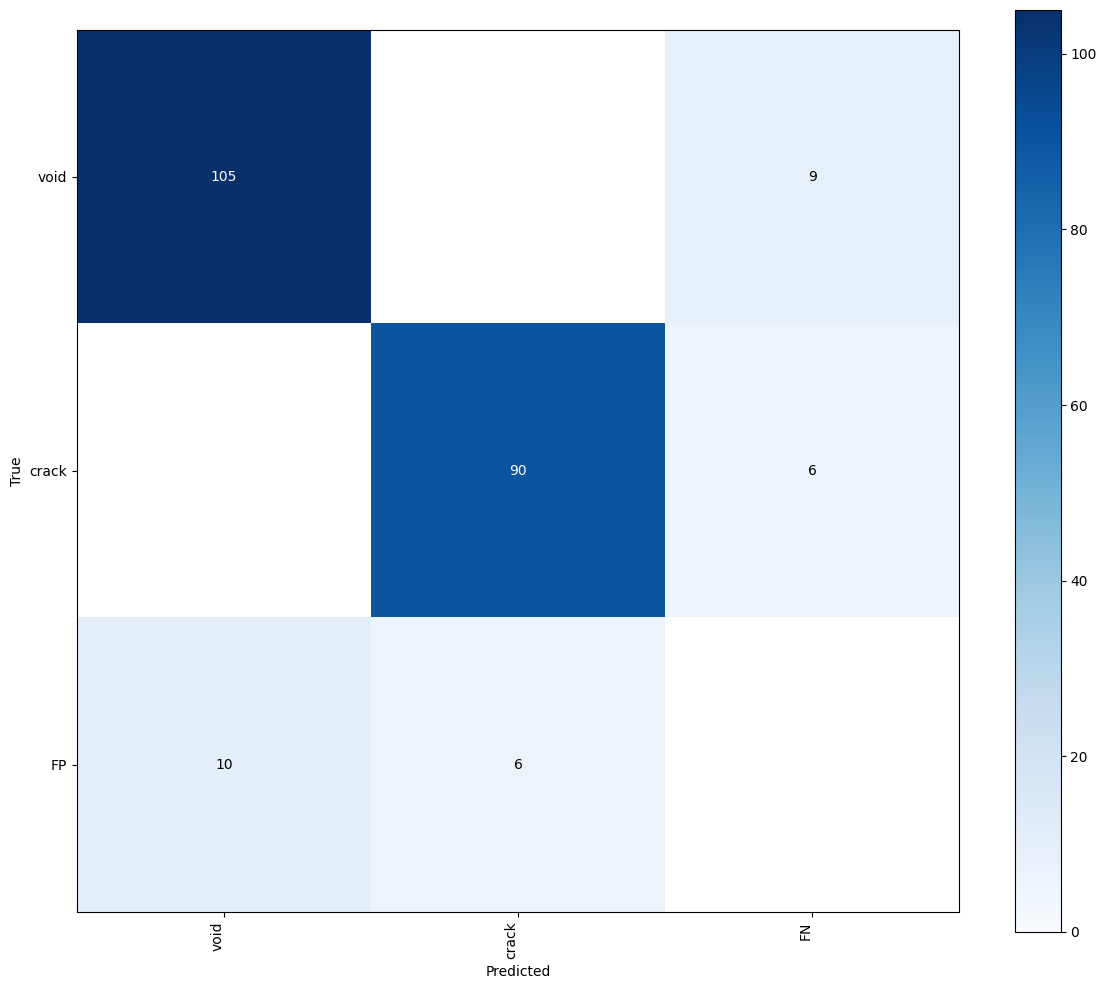

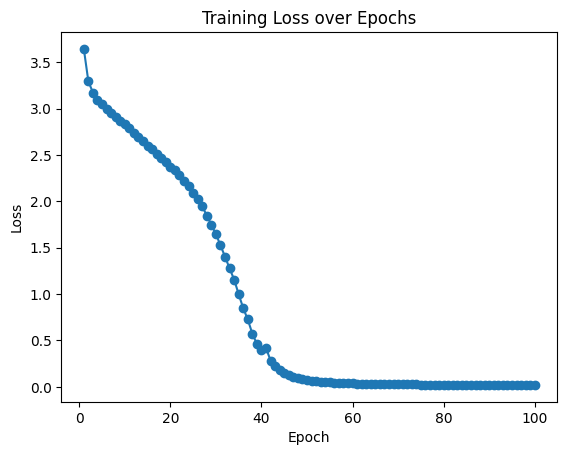

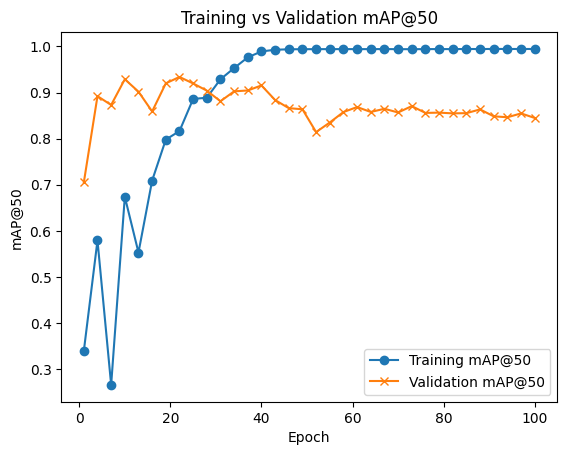

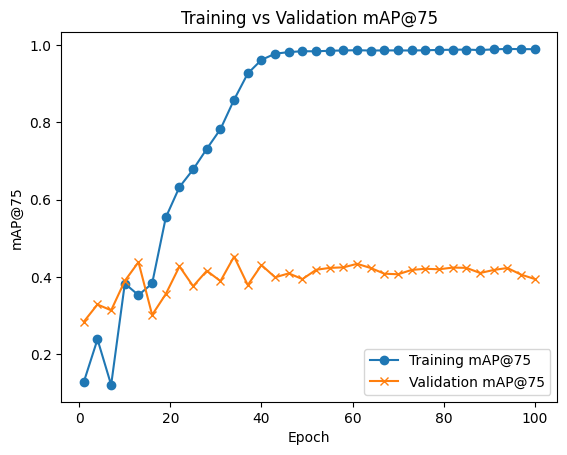

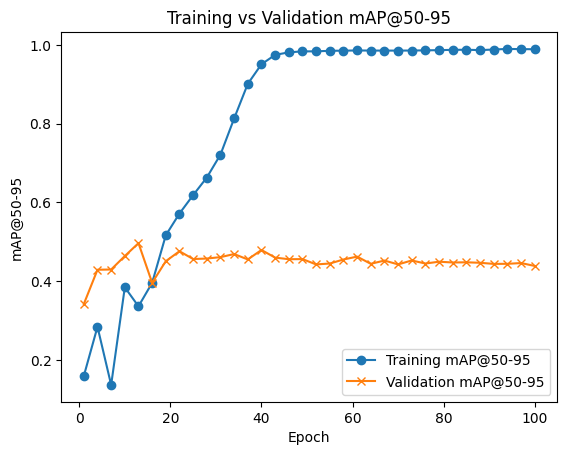

In [15]:
import time  
from tqdm import tqdm  
import numpy as np
import jax
import big_vision.utils
import matplotlib.pyplot as plt

# 设置参数
BATCH_SIZE = 8
TRAIN_EXAMPLES = 1974
LEARNING_RATE = 0.003
EPOCHS = 100

TRAIN_STEPS = TRAIN_EXAMPLES // BATCH_SIZE
EVAL_STEPS = TRAIN_STEPS // 8

train_data_it = train_data_iterator()

# 创建学习率调度器
sched_fn = big_vision.utils.create_learning_rate_schedule(
    total_steps=TRAIN_STEPS * EPOCHS, base=LEARNING_RATE,
    decay_type="cosine", warmup_percent=0.10)

# 初始化变量
start_time = time.time()  
step = 0
losses = []
best_map50_v = 0
best_params = None
best_confusion_matrix = None
train_metrics = {
    "map50_t": [],
    "map75_t": [],
    "map50_95_t": []
}
val_metrics = {
    "map50_v": [],
    "map75_v": [],
    "map50_95_v": []
}

def calculate_map(data_iterator, batch_size, classes):
    targets = []
    predictions = []
    for image, label, prediction in make_predictions(data_iterator, batch_size=batch_size):
        h, w, _ = image.shape
        target = sv.Detections.from_lmm(
            lmm='paligemma',
            result=label,
            resolution_wh=(w, h),
            classes=classes)
        targets.append(target)
        prediction = sv.Detections.from_lmm(
            lmm='paligemma',
            result=prediction,
            resolution_wh=(w, h),
            classes=classes)
        prediction.confidence = np.ones(len(prediction))
        predictions.append(prediction)

    mean_average_precision = sv.MeanAveragePrecision.from_detections(
        predictions=predictions,
        targets=targets,
    )

    return mean_average_precision.map50, mean_average_precision.map75, mean_average_precision.map50_95, predictions, targets

# 训练循环
for epoch in range(EPOCHS):
    epoch_start_time = time.time()  
    epoch_loss = 0
    pbar = tqdm(total=TRAIN_STEPS, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for _ in range(TRAIN_STEPS):
        step += 1
        examples = [next(train_data_it) for _ in range(BATCH_SIZE)]
        batch = jax.tree_map(lambda *x: np.stack(x), *examples)
        batch = big_vision.utils.reshard(batch, data_sharding)
        learning_rate = sched_fn(step)
        params, loss = update_fn(params, batch, learning_rate)
        loss = jax.device_get(loss)
        epoch_loss += loss
        pbar.update(1)

    pbar.close()
    epoch_loss /= TRAIN_STEPS
    losses.append(epoch_loss)
    epoch_end_time = time.time()
    elapsed_epoch_time = epoch_end_time - epoch_start_time  
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}, Time: {elapsed_epoch_time:.2f} sec")

    # 每3个epoch计算并保存mAP指标
    if (epoch + 1) % 3 == 0 or epoch == EPOCHS - 1:
        # 计算训练集上的评估指标
        map50_t, map75_t, map50_95_t, train_predictions, train_targets = calculate_map(validation_data_iterator_trained(), batch_size=8, classes=CLASSES)
        train_metrics["map50_t"].append(map50_t)
        train_metrics["map75_t"].append(map75_t)
        train_metrics["map50_95_t"].append(map50_95_t)

        # 计算验证集上的评估指标
        map50_v, map75_v, map50_95_v, val_predictions, val_targets = calculate_map(validation_data_iterator_valued(), batch_size=8, classes=CLASSES)
        val_metrics["map50_v"].append(map50_v)
        val_metrics["map75_v"].append(map75_v)
        val_metrics["map50_95_v"].append(map50_95_v)

        print(f"Epoch {epoch+1}/{EPOCHS} - mAP@50_t: {map50_t:.2f}, mAP@75_t: {map75_t:.2f}, mAP@50-95_t: {map50_95_t:.2f}, mAP@50_v: {map50_v:.2f}, mAP@75_v: {map75_v:.2f}, mAP@50-95_v: {map50_95_v:.2f}")

        # 保存最佳模型
        if map50_t >= 0.85 and map50_v > best_map50_v:
            best_map50_v = map50_v
            best_params = params
            best_confusion_matrix = sv.ConfusionMatrix.from_detections(
                predictions=val_predictions,
                targets=val_targets,
                classes=CLASSES
            )
            with open("/root/autodl-tmp/model-out-8-object/fine-tuned-paligemma-3b-pt-224.f16.npz", "wb") as f:
                flat, _ = big_vision.utils.tree_flatten_with_names(params)
                np.savez(f, **{k: v for k, v in flat})

            html_out = ""
            for image, _, caption in make_predictions(validation_data_iterator_valued(), num_examples=201, batch_size=4):
                html_out += render_example(image, caption)
            with open("/root/autodl-tmp/model-out-8-object/output_Evaluate.html", "w") as f:
                f.write(html_out)
            print("HTML 内容已保存到 output_Evaluate.html")

    # 在最后一个epoch保存最新的模型权重
    if epoch == EPOCHS - 1:
        with open("/root/autodl-tmp/model-out-8-object/latest_model_weights.npz", "wb") as f:
            flat, _ = big_vision.utils.tree_flatten_with_names(params)
            np.savez(f, **{k: v for k, v in flat})

end_time = time.time()  
elapsed_time = end_time - start_time  
print(f"程序运行时间: {elapsed_time:.2f} 秒")

# 绘制最佳模型的混淆矩阵图像
if best_confusion_matrix is not None:
    _ = best_confusion_matrix.plot()
    plt.savefig('/root/autodl-tmp/model-out-8-object/best_confusion_matrix.png')
    plt.show()

# 保存所有epoch的损失以便绘图
plt.plot(range(1, EPOCHS+1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()

# 保存训练集和验证集的mAP指标
plt.figure()
plt.plot(range(1, EPOCHS+1, 3), train_metrics["map50_t"], marker='o', label="Training mAP@50")
plt.plot(range(1, EPOCHS+1, 3), val_metrics["map50_v"], marker='x', label="Validation mAP@50")
plt.xlabel('Epoch')
plt.ylabel('mAP@50')
plt.title('Training vs Validation mAP@50')
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, EPOCHS+1, 3), train_metrics["map75_t"], marker='o', label="Training mAP@75")
plt.plot(range(1, EPOCHS+1, 3), val_metrics["map75_v"], marker='x', label="Validation mAP@75")
plt.xlabel('Epoch')
plt.ylabel('mAP@75')
plt.title('Training vs Validation mAP@75')
plt.legend()
plt.show()

plt.figure()
plt.plot(range(1, EPOCHS+1, 3), train_metrics["map50_95_t"], marker='o', label="Training mAP@50-95")
plt.plot(range(1, EPOCHS+1, 3), val_metrics["map50_95_v"], marker='x', label="Validation mAP@50-95")
plt.xlabel('Epoch')
plt.ylabel('mAP@50-95')
plt.title('Training vs Validation mAP@50-95')
plt.legend()
plt.show()


In [16]:
print(losses)

[3.6428603999983005, 3.2921308143352106, 3.172706737750914, 3.097179867387787, 3.044832764602289, 2.9952552589943737, 2.95223697317325, 2.910489694858954, 2.8679494276279356, 2.831134118684908, 2.7933486932661475, 2.7377975965903056, 2.691477140760034, 2.6496962163506486, 2.599632083885069, 2.5650735279408896, 2.510325832095573, 2.465585923776394, 2.4224909267774444, 2.3742491859730666, 2.335670867101933, 2.28098958197648, 2.2173633720816635, 2.1615781851900304, 2.0888676614296147, 2.0248137145507625, 1.946423276168544, 1.846115253805145, 1.7468206402732105, 1.6470561943403104, 1.5255828620941658, 1.4034617102243068, 1.2774918871681864, 1.1562728096799153, 0.9983269596487526, 0.8472595384450463, 0.7261200146219595, 0.5725987856465626, 0.4625372533512309, 0.3964778233955546, 0.4187125256209354, 0.28367122750335594, 0.22748101405738816, 0.18587834060918995, 0.14974509723242221, 0.12580449155312243, 0.10523585619298907, 0.09290137722694534, 0.08081088285529758, 0.07254150484847587, 0.0634

Object `figure` not found.


Object `figure` not found.
